# I used Python, pandas, NumPy, scikit-learn, and Jupyter Notebook because they are appropriate for tabular regression problems and allow repeatable preprocessing, model training, cross-validation, and evaluation. For larger datasets, this workflow could be scaled using SparkML or Dask to distribute preprocessing and training across multiple machines.

# Car Price Prediction Using Machine Learning

## Objective

The objective of this project is to develop a machine learning model capable of predicting vehicle prices based on vehicle characteristics such as brand, model, mileage, engine size, condition, and transmission type.

This project evaluates multiple machine learning algorithms and explores scalability considerations for larger datasets.

## Import Required Libraries

The following libraries are used throughout the project:

- Pandas for data manipulation and analysis
- NumPy for numerical operations
- Matplotlib for data visualization
- Scikit-learn for machine learning model development, evaluation, and hyperparameter tuning

These tools provide a scalable framework for preprocessing, training, and evaluating machine learning models.

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

## Load Dataset

The dataset contains vehicle information including brand, model, year, engine size, transmission type, fuel type, condition, mileage, and selling price.

The dataset is loaded into a Pandas DataFrame for analysis and preprocessing.

In [2]:
import pandas as pd

df = pd.read_csv("Downloads/CarPricePrediction/car_price_prediction_ (1).csv")

df.head()

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1,Tesla,2016,2.3,Petrol,Manual,114832,New,26613.92,Model X
1,2,BMW,2018,4.4,Electric,Manual,143190,Used,14679.61,5 Series
2,3,Audi,2013,4.5,Electric,Manual,181601,New,44402.61,A4
3,4,Tesla,2011,4.1,Diesel,Automatic,68682,New,86374.33,Model Y
4,5,Ford,2009,2.6,Diesel,Manual,223009,Like New,73577.10,Mustang


## Exploratory Data Analysis (EDA)

Before building machine learning models, the dataset is explored to understand its structure, identify missing values, inspect data types, and review summary statistics.

EDA helps identify potential data quality issues and provides insights into the distribution of variables.

In [3]:
print(df.shape)
print(df.info())
print(df.describe())

(2500, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Car ID        2500 non-null   int64  
 1   Brand         2500 non-null   object 
 2   Year          2500 non-null   int64  
 3   Engine Size   2500 non-null   float64
 4   Fuel Type     2500 non-null   object 
 5   Transmission  2500 non-null   object 
 6   Mileage       2500 non-null   int64  
 7   Condition     2500 non-null   object 
 8   Price         2500 non-null   float64
 9   Model         2500 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 195.4+ KB
None
           Car ID       Year  Engine Size        Mileage         Price
count  2500.00000  2500.0000  2500.000000    2500.000000   2500.000000
mean   1250.50000  2011.6268     3.465240  149749.844800  52638.022532
std     721.83216     6.9917     1.432053   87919.952034  27295.833455
min       1.0

# Target Variable Analysis

The target variable for this project is Price.

A histogram is created to visualize the distribution of vehicle prices and identify any potential skewness or outliers that may impact model performance.

In [4]:
df['Price'].describe()

count     2500.000000
mean     52638.022532
std      27295.833455
min       5011.270000
25%      28908.485000
50%      53485.240000
75%      75838.532500
max      99982.590000
Name: Price, dtype: float64

# Price Distribution

A histogram is used to visualize the distribution of vehicle prices. Understanding the target variable distribution helps identify skewness, unusual patterns, or potential outliers that may affect model performance.

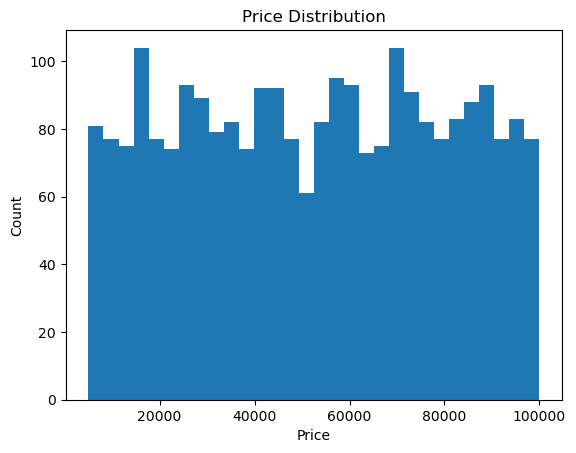

In [5]:
import matplotlib.pyplot as plt

plt.hist(df['Price'], bins=30)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

## Data Preprocessing

Machine learning algorithms require numerical inputs. Therefore, categorical features such as Brand, Fuel Type, Transmission, Condition, and Model are converted into numerical representations using one-hot encoding.

This process creates binary indicator variables that allow machine learning models to utilize categorical information.

In [6]:
df_encoded = pd.get_dummies(
    df,
    columns=[
        'Brand',
        'Fuel Type',
        'Transmission',
        'Condition',
        'Model'
    ],
    drop_first=True
)

# Train-Test Split

The dataset is divided into training and testing datasets.

The training dataset is used to train machine learning models, while the testing dataset is reserved for evaluating model performance on unseen data.

An 80/20 split is used to balance model training and evaluation.

In [7]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop('Price', axis=1)
y = df_encoded['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Model 1: Linear Regression

Linear Regression serves as a baseline machine learning model for predicting vehicle prices.

This model assumes a linear relationship between the predictor variables and the target variable.

In [22]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

# Model 2: Random Forest Regressor

Random Forest is an ensemble learning algorithm that combines multiple decision trees.

This technique can capture nonlinear relationships and often performs well on structured tabular datasets.

In [9]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

# Model 3: Gradient Boosting Regressor

Gradient Boosting builds multiple trees sequentially, with each new tree attempting to correct errors from previous trees.

This model is frequently used for regression problems because of its strong predictive capabilities.

In [10]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(
    random_state=42
)

gb.fit(X_train, y_train)

GradientBoostingRegressor(random_state=42)

# Cross Validation

Five-fold cross-validation is used to evaluate model performance across multiple subsets of the dataset.

Cross-validation provides a more reliable estimate of model performance and reduces the risk of selecting a model based on a single train-test split.

In [11]:
from sklearn.model_selection import cross_val_score

rf_cv = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring='r2'
)

print(rf_cv.mean())

-0.05973177365018647


# Hyperparameter Tuning

GridSearchCV is used to evaluate multiple Random Forest parameter combinations.

The objective is to identify the combination of hyperparameters that produces the highest cross-validation performance.

In [13]:
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators':[100,200],
    'max_depth':[10,20,None]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    params,
    cv=5,
    scoring='r2'
)

grid.fit(X_train,y_train)

print(grid.best_params_)

{'max_depth': 10, 'n_estimators': 100}


In [14]:
results = pd.DataFrame(grid.cv_results_)

results[['param_n_estimators',
         'param_max_depth',
         'mean_test_score',
         'rank_test_score']]

,param_n_estimators,param_max_depth,mean_test_score,rank_test_score
0,100,10,-0.027726,1
1,200,10,-0.028494,2
2,100,20,-0.055829,4
3,200,20,-0.053098,3
4,100,None,-0.057212,6
5,200,None,-0.056475,5


In [15]:
print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

best_rf = grid.best_estimator_

train_score = best_rf.score(X_train, y_train)
test_score = best_rf.score(X_test, y_test)

print("Train R²:", train_score)
print("Test R²:", test_score)

Best Parameters: {'max_depth': 10, 'n_estimators': 100}
Best CV Score: -0.027725563897899264
Train R²: 0.40501240134937944
Test R²: -0.01866760307160864


# Correlation Analysis

Correlation analysis is performed to evaluate relationships between numerical features and vehicle price.

Strong correlations may indicate useful predictive features, while weak correlations suggest limited predictive power.

In [16]:
df.corr(numeric_only=True)

,Car ID,Year,Engine Size,Mileage,Price
Car ID,1.000000,0.008050,0.000059,-0.035840,0.004650
Year,0.008050,1.000000,0.011833,0.002282,-0.036805
Engine Size,0.000059,0.011833,1.000000,-0.015782,-0.004420
Mileage,-0.035840,0.002282,-0.015782,1.000000,-0.008567
Price,0.004650,-0.036805,-0.004420,-0.008567,1.000000


# Correlation Interpretation

The strongest numerical correlation with vehicle price was Year (-0.0368), while Engine Size (-0.0044) and Mileage (-0.0086) showed almost no relationship with Price.

These extremely weak correlations suggest that the available features contain limited predictive information, which helps explain the poor performance of the machine learning models.

# The Random Forest model achieved a training R² of 0.405 but failed to generalize to unseen data, producing a negative test R² score. This suggests the model was fitting noise in the training data rather than learning meaningful pricing relationships.

# Model Comparison Results

Three machine learning algorithms were evaluated to determine their ability to predict vehicle prices.

The models were compared using training and testing R² scores to evaluate both learning performance and generalization capability.

In [25]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

lr_train = lr.score(X_train, y_train)
lr_test = lr.score(X_test, y_test)

# Random Forest
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

rf_train = rf.score(X_train, y_train)
rf_test = rf.score(X_test, y_test)

# Gradient Boosting
gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)

gb_train = gb.score(X_train, y_train)
gb_test = gb.score(X_test, y_test)

In [27]:
comparison = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest',
        'Gradient Boosting'
    ],
    'Train R²': [
        lr_train,
        rf_train,
        gb_train
    ],
    'Test R²': [
        lr_test,
        rf_test,
        gb_test
    ]
})

comparison.round(4)

,Model,Train R²,Test R²
0,Linear Regression,0.0197,-0.0202
1,Random Forest,0.8517,-0.0427
2,Gradient Boosting,0.1786,-0.0111


# Analysis of Results

The Random Forest model achieved the highest training R² score but produced a negative testing R² score, indicating poor generalization to unseen data.

The negative testing scores across the models suggest that the available features contain limited predictive information regarding vehicle prices. Correlation analysis supports this conclusion, showing extremely weak relationships between the numerical features and the target variable.

Although predictive performance was limited, the project successfully demonstrated data preprocessing, model comparison, cross-validation, hyperparameter tuning, and scalability planning.

# Scaling the Machine Learning Prototype

The current prototype uses scikit-learn and processes approximately 2,500 vehicle records on a single machine.

For larger real-world datasets containing millions of vehicle records, the workflow could be scaled using distributed machine learning frameworks such as SparkML, Dask, TensorFlow, or PyTorch.

### Trade-Offs

- Linear Regression trains quickly and requires minimal computational resources but may underfit complex relationships.
- Random Forest and Gradient Boosting often improve predictive performance but require more memory and longer training times.
- Distributed frameworks improve scalability for large datasets but increase infrastructure complexity and operational costs.

Although this dataset is relatively small, the preprocessing and model training pipeline can be extended to larger datasets without major modifications.

# Conclusion

Multiple algorithms were evaluated using cross-validation and train/test evaluation.

The analysis revealed weak relationships between the available features and vehicle price, limiting predictive performance across all models.

Despite these limitations, the project successfully demonstrates a complete machine learning workflow including preprocessing, model training, model evaluation, hyperparameter optimization, cross-validation, and scalability planning.